# Merge e EDA complementar — imóveis e informações por CEP

**Moeda adotada:** dólar americano (USD), por premissa do projeto baseada no contexto de Seattle. Não houve conversão cambial nem alteração dos valores. A fonte não confirmou explicitamente a moeda. Preços e erros monetários estão em USD; percentuais, R² e contribuições SHAP em log mantêm suas próprias escalas.

## Objetivo
Associar cada imóvel aos indicadores demográficos de seu CEP, conferir se a junção preserva os dados e investigar quais relações aparecem entre características regionais e preços.

Usaremos o **histórico completo**, sem separar treino, validação ou teste nesta etapa. O fluxo é: EDA geral → merge → EDA complementar → preparação das variáveis → split e modelagem.

As interpretações dos indicadores continuam sendo hipóteses baseadas nos nomes. Não recebemos documentação suficiente para confirmar unidades, cálculos ou datas de referência. Correlação não prova causa nem ganho de precisão de um modelo.

**Execução:** selecione o Python da `.venv` e execute todas as células em ordem. Este notebook lê os arquivos de `data/raw/` diretamente e não depende da memória do notebook 01. Os dados combinados vão para `data/processed/`; tabelas, figuras e um registro das fontes vão para `reports/`. Nenhum arquivo original será alterado.

In [1]:
# Prepara as bibliotecas e os caminhos do projeto.
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display as exibir

PASTA_PROJETO = Path.cwd()
if not (PASTA_PROJETO / "data" / "raw").is_dir():
    PASTA_PROJETO = PASTA_PROJETO.parent
if not ((PASTA_PROJETO / "data" / "raw").is_dir()):
    raise ValueError("Execute na raiz ou em notebooks.")

PASTA_ORIGINAIS = PASTA_PROJETO / "data" / "raw"
PASTA_TRATADOS = PASTA_PROJETO / "data" / "processed"
PASTA_RESULTADOS = PASTA_PROJETO / "reports" / "metrics"
PASTA_GRAFICOS = PASTA_PROJETO / "reports" / "figures"
for pasta in [PASTA_TRATADOS, PASTA_RESULTADOS, PASTA_GRAFICOS]:
    pasta.mkdir(parents=True, exist_ok=True)

imoveis = pd.read_csv(PASTA_ORIGINAIS / "kc_house_data.csv",
                     dtype={"id": "string", "zipcode": "string"})
demografia = pd.read_csv(PASTA_ORIGINAIS / "zipcode_demographics.csv",
                        dtype={"zipcode": "string"})
exemplos_futuros = pd.read_csv(PASTA_ORIGINAIS / "future_unseen_examples.csv",
                             dtype={"zipcode": "string"})
tabelas = {"historico": imoveis, "demografia": demografia, "futuros": exemplos_futuros}
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True})
exibir(pd.DataFrame([
    {"arquivo": nome, "linhas": len(tabela), "colunas": tabela.shape[1]}
    for nome, tabela in tabelas.items()
]))

,arquivo,linhas,colunas
0,historico,21613,21
1,demografia,70,27
2,futuros,100,18


**O que o resultado mostra**

Temos 21.613 linhas históricas, 70 linhas demográficas e 100 exemplos futuros. São arquivos com funções diferentes: venda, região e entrada para previsão.

**Por que fizemos esta análise e o que decidimos**

A leitura independente permite repetir o notebook sem executar o anterior. CEP e ID são texto porque identificam regiões e imóveis, não representam quantidades.

## 1. Preparando a chave da junção

O CEP funciona como uma etiqueta: buscamos na tabela demográfica a linha com a mesma etiqueta do imóvel. Removemos espaços e verificamos cinco dígitos, formato observado nestes arquivos. Não tentamos adivinhar um CEP malformado.

In [2]:
# Padroniza CEPs e confere se a tabela regional tem uma linha por chave.
diagnostico_ceps = []
for nome, tabela in tabelas.items():
    tabela["zipcode"] = tabela["zipcode"].str.strip()
    formato_valido = tabela["zipcode"].str.fullmatch(r"\d{5}", na=False)
    diagnostico_ceps.append({
        "arquivo": nome,
        "ceps_ausentes": int(tabela["zipcode"].isna().sum()),
        "ceps_fora_do_formato": int((~formato_valido).sum()),
        "ceps_distintos": tabela["zipcode"].nunique(),
        "repeticoes_alem_da_primeira": int(tabela["zipcode"].duplicated().sum()),
    })
    if not (formato_valido.all()):
        raise ValueError(f"Investigar CEPs no arquivo {nome}.")

if not (demografia["zipcode"].is_unique):
    raise ValueError("Resolver CEPs demográficos duplicados antes do merge.")
indicadores_demograficos = demografia.columns.drop("zipcode").tolist()
if set(indicadores_demograficos) & set(imoveis.columns):
    raise ValueError('Há nomes de indicadores demográficos em conflito com as colunas dos imóveis.')
if set(indicadores_demograficos) & set(exemplos_futuros.columns):
    raise ValueError('Há nomes de indicadores demográficos em conflito com as colunas dos imóveis.')
exibir(pd.DataFrame(diagnostico_ceps))

,arquivo,ceps_ausentes,ceps_fora_do_formato,ceps_distintos,repeticoes_alem_da_primeira
0,historico,0,0,70,21543
1,demografia,0,0,70,0
2,futuros,0,0,45,55


**O que o resultado mostra**

Os CEPs estão preenchidos e seguem o formato esperado. Há uma linha demográfica por CEP. Repetições de CEP no histórico e nos exemplos futuros são esperadas: vários imóveis podem pertencer à mesma região.

**Por que fizemos esta análise e o que decidimos**

A unicidade só é obrigatória na tabela demográfica. Se ela tivesse duas linhas para um CEP, uma venda poderia se multiplicar ao conectar as tabelas. Por isso, interrompemos o processo se a chave regional estiver duplicada.

## 2. Associando as tabelas e preservando as vendas

Usaremos uma **junção à esquerda**: todas as linhas dos imóveis permanecem, com ou sem correspondência regional. A validação **muitos para um** exige uma única linha demográfica para cada CEP. A função abaixo será aplicada tanto ao histórico quanto aos exemplos futuros.

In [3]:
# Junta as tabelas e verifica quantidade, ordem e conteúdo das colunas originais.
def juntar_por_cep(tabela_imoveis, tabela_demografica):
    tabela_com_ordem = tabela_imoveis.copy()
    tabela_com_ordem["_ordem_original"] = np.arange(len(tabela_imoveis))

    tabela_combinada = tabela_com_ordem.merge(
        tabela_demografica, on="zipcode", how="left",
        validate="many_to_one", indicator="_situacao_merge", sort=False,
    ).sort_values("_ordem_original", kind="stable").reset_index(drop=True)

    # Uma conferência cobre valores, quantidade e ordem das linhas originais.
    if not tabela_combinada[tabela_imoveis.columns].equals(tabela_imoveis.reset_index(drop=True)):
        raise ValueError("O merge alterou as linhas ou os valores originais.")
    return tabela_combinada.drop(columns="_ordem_original")

imoveis_com_demografia = juntar_por_cep(imoveis, demografia)
futuros_com_demografia = juntar_por_cep(exemplos_futuros, demografia)

integridade_merge = pd.DataFrame([
    {"arquivo": nome, "linhas_antes": len(original),
     "linhas_depois": len(combinada),
     "colunas_originais": original.shape[1],
     "indicadores_adicionados": len(indicadores_demograficos),
     "linhas_sem_correspondencia": int(combinada["_situacao_merge"].eq("left_only").sum()),
     "celulas_demograficas_ausentes": int(combinada[indicadores_demograficos].isna().sum().sum())}
    for nome, original, combinada in [
        ("historico", imoveis, imoveis_com_demografia),
        ("futuros", exemplos_futuros, futuros_com_demografia),
    ]
])
integridade_merge.to_csv(PASTA_RESULTADOS / "merge_integridade.csv", index=False)
exibir(integridade_merge)

,arquivo,linhas_antes,linhas_depois,colunas_originais,indicadores_adicionados,linhas_sem_correspondencia,celulas_demograficas_ausentes
0,historico,21613,21613,21,26,0,0
1,futuros,100,100,18,26,0,0


**O que o resultado mostra**

A junção preserva 21.613 vendas e 100 exemplos futuros e acrescenta 26 indicadores. Não há linhas sem correspondência ou células demográficas ausentes. As verificações também confirmam a ordem e o conteúdo das colunas originais.

**Por que fizemos esta análise e o que decidimos**

Precisamos garantir que a junção não altera preços, não duplica vendas e não troca a ordem dos exemplos futuros. Cobertura completa neste arquivo não garante cobertura para novos CEPs, nem confirma a qualidade ou a data dos indicadores.

In [4]:
# Mostra uma amostra da associação entre casa, CEP e indicadores regionais.
colunas_exemplo = ["id", "zipcode", "price", "sqft_living",
                   "medn_hshld_incm_amt", "medn_incm_per_prsn_amt", "hous_val_amt"]
exibir(imoveis_com_demografia[colunas_exemplo].head(8))

,id,zipcode,price,sqft_living,medn_hshld_incm_amt,medn_incm_per_prsn_amt,hous_val_amt
0,7129300520,98178,221900.0,1180,47461.0,22158.0,175400.0
1,6414100192,98125,538000.0,2570,42400.0,25771.0,225900.0
2,5631500400,98028,180000.0,770,61813.0,31765.0,246600.0
3,2487200875,98136,604000.0,1960,56455.0,39232.0,280200.0
4,1954400510,98074,510000.0,1680,56933.0,27639.5,239850.0
5,7237550310,98053,1225000.0,5420,96028.0,41052.0,349000.0
6,1321400060,98003,257500.0,1715,43027.0,21092.0,166800.0
7,2008000270,98198,291850.0,1060,46628.0,22518.0,171300.0


**O que o resultado mostra**

Cada venda agora reúne características físicas e informações do CEP. Preços continuam sendo valores individuais da venda; os indicadores demográficos pertencem à região e se repetem quando outras vendas têm o mesmo CEP.

**Por que fizemos esta análise e o que decidimos**

A amostra torna a junção concreta para quem lê o projeto. O valor de renda do CEP não deve ser apresentado como renda do comprador ou morador, e `hous_val_amt` não foi usado para substituir o preço.

**Hipótese**

Os indicadores regionais podem acrescentar contexto que área e quantidade de quartos não representam. Essa contribuição precisa ser testada em modelos, não é comprovada pela junção.

In [5]:
# Simula um CEP sem cadastro, apenas para verificar o comportamento da função.
assert "00000" not in set(demografia["zipcode"])
exemplo_sem_cep = exemplos_futuros.head(1).copy()
exemplo_sem_cep["zipcode"] = pd.Series(["00000"], index=exemplo_sem_cep.index, dtype="string")
resultado_simulado = juntar_por_cep(exemplo_sem_cep, demografia)
assert len(resultado_simulado) == 1
assert resultado_simulado["_situacao_merge"].iloc[0] == "left_only"
assert resultado_simulado[indicadores_demograficos].isna().all().all()
exibir(resultado_simulado[["zipcode", "_situacao_merge", "medn_hshld_incm_amt"]])

,zipcode,_situacao_merge,medn_hshld_incm_amt
0,00000,left_only,NaN


**O que o resultado mostra**

O exemplo artificial permanece na tabela e recebe indicadores ausentes quando seu CEP não está cadastrado. `left_only` significa que encontramos apenas a linha original do imóvel.

**Por que fizemos esta análise e o que decidimos**

Esse caso verifica um comportamento importante para novos dados. A linha simulada não será incluída em nenhuma análise ou exportação. A política futura de preenchimento será definida na preparação e ajustada somente no treino.

## 3. EDA complementar: cada venda ou cada CEP?

Na tabela combinada, regiões com mais vendas aparecem mais vezes. Vamos criar uma tabela descritiva com **uma linha por CEP**, para também comparar regiões com o mesmo peso. O preço mediano regional usa os preços históricos apenas nesta EDA: não será exportado como variável pronta para treinar o modelo.

In [6]:
# Resume vendas por CEP e associa uma única linha de indicadores regionais.
resumo_por_cep = imoveis_com_demografia.groupby("zipcode", as_index=False).agg(
    quantidade_vendas=("price", "size"),
    preco_mediano=("price", "median"),
    area_mediana=("sqft_living", "median"),
    grade_mediano=("grade", "median"),
).merge(demografia, on="zipcode", how="left", validate="one_to_one")

resumo_por_cep.to_csv(PASTA_RESULTADOS / "eda_pos_merge_por_cep.csv", index=False)
exibir(resumo_por_cep[
    ["zipcode", "quantidade_vendas", "preco_mediano", "area_mediana", "grade_mediano"]
].sort_values("quantidade_vendas", ascending=False))

,zipcode,quantidade_vendas,preco_mediano,area_mediana,grade_mediano
42,98103,602,550000.0,1505.0,7.0
23,98038,590,342000.0,2000.0,7.0
49,98115,583,567000.0,1710.0,7.0
28,98052,574,615000.0,2299.0,8.0
51,98117,553,544000.0,1550.0,7.0
...,...,...,...,...,...
41,98102,105,720000.0,1800.0,8.0
8,98010,100,359999.5,1902.0,7.0
14,98024,81,460000.0,1950.0,7.0
61,98148,57,278000.0,1570.0,7.0


**O que o resultado mostra**

Os 70 CEPs têm entre 50 e 602 vendas. Portanto, numa análise por venda, alguns CEPs aparecem mais de dez vezes mais que outros. A tabela mostra também o preço, a área e a classificação medianos de cada região.

**Por que fizemos esta análise e o que decidimos**

As duas leituras respondem perguntas diferentes: por venda descreve as transações da amostra; por CEP descreve diferenças regionais com peso igual. As 21.613 linhas não representam 21.613 observações demográficas independentes, pois existem somente 70 conjuntos de indicadores.

**Hipótese**

Parte das diferenças de preço entre CEPs pode refletir o tamanho e o padrão das casas vendidas, e não apenas o contexto demográfico. Comparar regiões sem considerar essa composição pode levar a explicações incompletas.

In [7]:
# Compara associações por venda e por CEP, usando a ordem dos valores.
correlacao_por_venda = imoveis_com_demografia[
    indicadores_demograficos + ["price"]
].corr(method="spearman")["price"].drop("price")
correlacao_por_cep = resumo_por_cep[
    indicadores_demograficos + ["preco_mediano"]
].corr(method="spearman")["preco_mediano"].drop("preco_mediano")

comparacao_associacoes = pd.DataFrame({
    "por_venda": correlacao_por_venda,
    "por_cep": correlacao_por_cep,
})
comparacao_associacoes = comparacao_associacoes.loc[
    comparacao_associacoes["por_cep"].abs().sort_values(ascending=False).index
]
comparacao_associacoes.to_csv(PASTA_RESULTADOS / "eda_pos_merge_associacoes.csv")
exibir(comparacao_associacoes.round(3))

,por_venda,por_cep
hous_val_amt,0.677,0.913
per_hsd,-0.642,-0.888
per_bchlr,0.650,0.886
per_prfsnl,0.649,0.879
medn_incm_per_prsn_amt,0.624,0.845
per_9_to_12,-0.559,-0.792
per_less_than_9,-0.474,-0.672
edctn_9_12_qty,-0.508,-0.662
edctn_high_schl_qty,-0.512,-0.654
edctn_prfsnl_qty,0.497,0.624


**O que o resultado mostra**

A associação de `medn_incm_per_prsn_amt` com preço é aproximadamente 0,624 por venda e 0,845 por CEP. Para `hous_val_amt`, passa de 0,677 para 0,913. As medidas são diferentes porque uma usa preços individuais e a outra usa medianas regionais com peso igual por CEP.

**Por que fizemos esta análise e o que decidimos**

Spearman varia de −1 a 1 e descreve se valores maiores costumam acompanhar valores maiores ou menores. Não é percentual de acerto nem prova causal. Agregar por CEP reduz variação entre imóveis dentro de uma região e altera os pesos; correlações maiores nessa tabela não comprovam melhora do modelo.

**Hipótese**

Alguns indicadores podem acompanhar características de localização compartilhadas por várias casas. A relação forte de `hous_val_amt` também é compatível com sua possível definição de valor habitacional, mas só a documentação pode esclarecer seu cálculo e disponibilidade temporal.

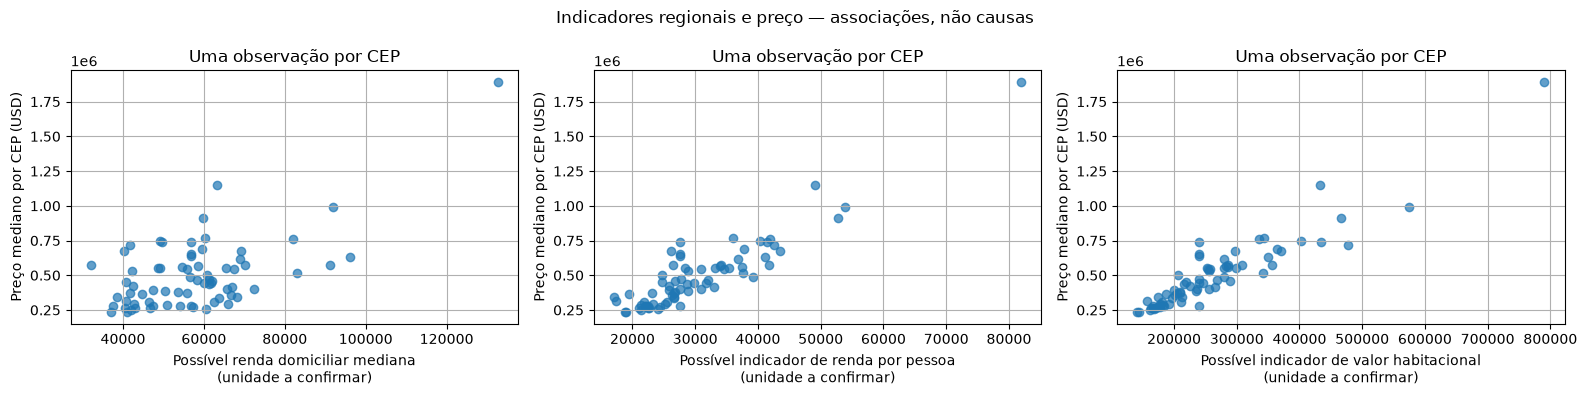

In [8]:
# Visualiza relações regionais; cada ponto representa um CEP.
indicadores_grafico = {
    "medn_hshld_incm_amt": "Possível renda domiciliar mediana",
    "medn_incm_per_prsn_amt": "Possível indicador de renda por pessoa",
    "hous_val_amt": "Possível indicador de valor habitacional",
}
figura, eixos = plt.subplots(1, 3, figsize=(16, 4))
for eixo, (coluna, rotulo) in zip(eixos, indicadores_grafico.items()):
    eixo.scatter(resumo_por_cep[coluna], resumo_por_cep["preco_mediano"], alpha=0.7)
    eixo.set(xlabel=rotulo + "\n(unidade a confirmar)",
             ylabel="Preço mediano por CEP (USD)", title="Uma observação por CEP")
figura.suptitle("Indicadores regionais e preço — associações, não causas")
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "eda_pos_merge_indicadores_preco.png", dpi=150)
plt.show()

**O que o resultado mostra**

Os gráficos permitem comparar o preço mediano das regiões com três indicadores. A relação por CEP é mais forte para renda por pessoa e valor habitacional que para renda domiciliar: os coeficientes da tabela anterior são aproximadamente 0,845, 0,913 e 0,391, respectivamente.

**Por que fizemos esta análise e o que decidimos**

Mostramos pontos em vez de apenas coeficientes para tornar visíveis dispersão e observações afastadas. A fonte não confirmou moeda nem definição de renda; não interpretaremos o eixo como renda de indivíduos nem converteremos associações em recomendações causais.

**Hipótese**

Diferenças na composição dos domicílios, no tipo de imóvel e na localização podem explicar por que os dois indicadores de renda têm associações diferentes. São possibilidades a investigar, não explicações demonstradas.

In [9]:
# Compara grupos de CEPs por faixas do possível indicador de renda.
resumo_por_cep["faixa_renda"] = pd.qcut(
    resumo_por_cep["medn_incm_per_prsn_amt"], q=4,
    labels=["1 - menor indicador", "2 - intermediário", "3 - intermediário", "4 - maior indicador"],
)
resumo_faixas = resumo_por_cep.groupby("faixa_renda", observed=True).agg(
    quantidade_ceps=("zipcode", "size"),
    vendas_representadas=("quantidade_vendas", "sum"),
    mediana_dos_precos_medianos=("preco_mediano", "median"),
    mediana_das_areas_medianas=("area_mediana", "median"),
    mediana_das_grades_medianas=("grade_mediano", "median"),
)
resumo_faixas.to_csv(PASTA_RESULTADOS / "eda_pos_merge_faixas_renda.csv")
exibir(resumo_faixas)

,quantidade_ceps,vendas_representadas,mediana_dos_precos_medianos,mediana_das_areas_medianas,mediana_das_grades_medianas
faixa_renda,,,,,
1 - menor indicador,18,5056,278138.5,1657.5,7.0
2 - intermediário,19,6388,399500.0,1915.0,7.0
3 - intermediário,15,5017,470000.0,1935.0,7.0
4 - maior indicador,18,5152,704900.0,2217.5,8.0


**O que o resultado mostra**

As faixas contêm 18, 19, 15 e 18 CEPs; valores repetidos do indicador fazem os tamanhos diferirem. A mediana dos preços medianos regionais cresce de 278.138,50 na primeira faixa para 704.900 na última. A área mediana regional resumida cresce de 1.657,5 para 2.217,5, e o resumo de grade passa de 7 para 8. A tabela permite comparar preço, área e classificação medianos junto com o número de CEPs e de vendas. `mediana_dos_precos_medianos` é o centro dos preços medianos regionais; não é a mediana de todas as vendas reunidas.

**Por que fizemos esta análise e o que decidimos**

Criamos faixas relativas à amostra para facilitar a comunicação, sem rotular grupos como classes sociais. As faixas são apenas descritivas, não entradas definitivas do modelo. Não têm necessariamente a mesma quantidade de vendas.

**Hipótese**

Se preços maiores vierem acompanhados de mudanças na área ou na classificação das casas, a composição dos imóveis pode explicar parte da diferença. A tabela não isola o efeito da renda; a hipótese precisa de análise controlada.

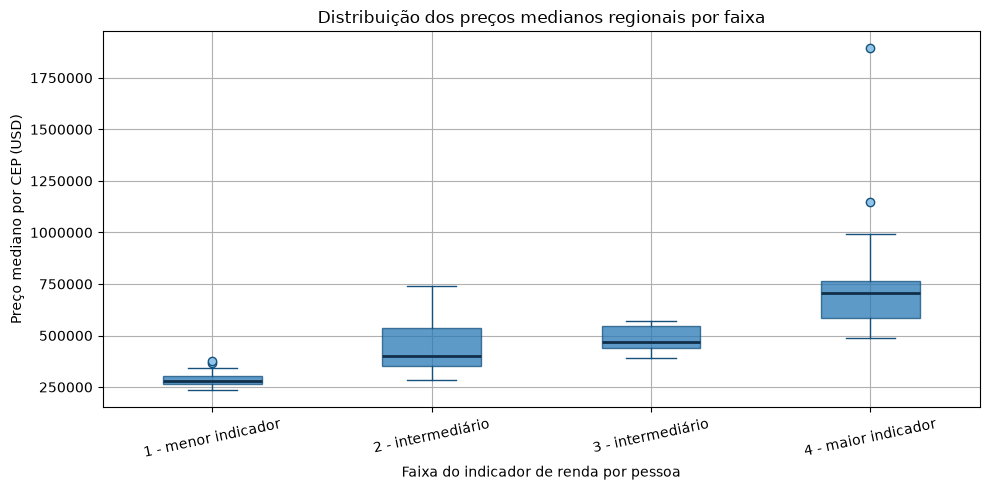

In [10]:
# Mostra as medianas regionais por faixa, preservando o peso igual dos CEPs.
grupos_precos = [
    resumo_por_cep.loc[resumo_por_cep["faixa_renda"] == faixa, "preco_mediano"].to_numpy()
    for faixa in resumo_faixas.index
]
figura, eixo = plt.subplots(figsize=(10, 5))
eixo.boxplot(
    grupos_precos, tick_labels=resumo_faixas.index.tolist(), patch_artist=True,
    boxprops={"facecolor": "#2878B5", "edgecolor": "#15517D", "alpha": 0.75},
    medianprops={"color": "#102F49", "linewidth": 2},
    whiskerprops={"color": "#15517D"}, capprops={"color": "#15517D"},
    flierprops={"markeredgecolor": "#15517D", "markerfacecolor": "#90C4E8"},
)
eixo.set(ylabel="Preço mediano por CEP (USD)", xlabel="Faixa do indicador de renda por pessoa",
         title="Distribuição dos preços medianos regionais por faixa")
eixo.ticklabel_format(axis="y", style="plain")
eixo.tick_params(axis="x", labelrotation=12)
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "eda_pos_merge_faixas_renda.png", dpi=150)
plt.show()

**O que o resultado mostra**

As linhas centrais das quatro faixas sobem, mas existem variações dentro de cada faixa e sobreposição entre algumas delas. A faixa de maior indicador apresenta CEPs com preços medianos especialmente altos. Cada caixa resume os preços medianos dos CEPs de uma faixa. A linha central é a mediana; a caixa contém a metade central dos valores. As hastes seguem o limite de 1,5 vez o intervalo da caixa, e pontos além delas representam valores afastados, não erros confirmados.

**Por que fizemos esta análise e o que decidimos**

A distribuição mostra diferenças dentro de cada faixa que uma única média esconderia. Os limites verticais indicam preço, não renda. Sobreposição entre grupos significa que conhecer a faixa não determina o preço de uma região ou imóvel.

**Hipótese**

Outros fatores, como localização e perfil das casas, podem fazer regiões de uma mesma faixa terem preços diferentes. O gráfico ajuda a formular essa hipótese, mas não identifica qual fator explica cada caso.

In [11]:
# Identifica os CEPs mostrados como pontos fora das hastes de cada caixa.
diagnostico_caixas = resumo_por_cep[["zipcode", "faixa_renda", "preco_mediano", "quantidade_vendas"]].copy()
precos_por_faixa = diagnostico_caixas.groupby("faixa_renda", observed=True)["preco_mediano"]
quartil_inferior = precos_por_faixa.transform("quantile", 0.25)
quartil_superior = precos_por_faixa.transform("quantile", 0.75)
distancia_quartis = quartil_superior - quartil_inferior
diagnostico_caixas["fora_da_caixa"] = (
    (diagnostico_caixas["preco_mediano"] < quartil_inferior - 1.5 * distancia_quartis) |
    (diagnostico_caixas["preco_mediano"] > quartil_superior + 1.5 * distancia_quartis)
)
ceps_fora_das_hastes = diagnostico_caixas.loc[diagnostico_caixas["fora_da_caixa"]].copy()
ceps_fora_das_hastes.to_csv(PASTA_RESULTADOS / "eda_pos_merge_outliers_boxplot.csv", index=False)
exibir(ceps_fora_das_hastes.drop(columns="fora_da_caixa"))

,zipcode,faixa_renda,preco_mediano,quantidade_vendas
3,98004,4 - maior indicador,1150000.0,317
24,98039,4 - maior indicador,1892500.0,50
52,98118,1 - menor indicador,367500.0,508
57,98133,1 - menor indicador,375000.0,494


**O que o resultado mostra**

Os pontos isolados são quatro CEPs: 98118 e 98133 na faixa de menor indicador, com preços medianos de 367.500 e 375.000; 98004 e 98039 na faixa de maior indicador, com 1.150.000 e 1.892.500. Os dois primeiros pontos estão muito próximos visualmente. A tabela permite identificá-los separadamente. Cada ponto representa o preço mediano de uma região em relação à sua faixa do indicador de renda; não é uma venda individual.

**Por que fizemos esta análise e o que decidimos**

Esse detalhe evita confundir três coisas: o extremo de uma venda no histórico, o extremo de uma venda dentro do CEP e o extremo da mediana de um CEP dentro de uma faixa. O boxplot usa a terceira comparação. Esses CEPs permanecem na análise.

**Hipótese**

Regiões com preço mediano distante da própria faixa podem diferir em localização, área, padrão das casas ou na definição do indicador. A distância estatística indica investigação, não exclusão automática.

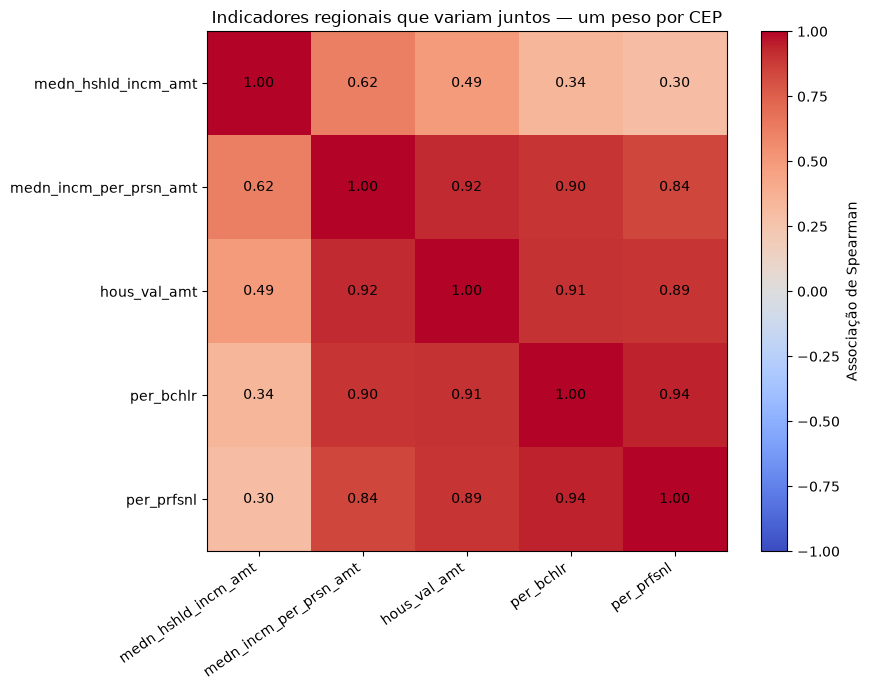

In [12]:
# Investiga indicadores que podem carregar informação semelhante.
colunas_redundancia = ["medn_hshld_incm_amt", "medn_incm_per_prsn_amt",
                      "hous_val_amt", "per_bchlr", "per_prfsnl"]
matriz_indicadores = resumo_por_cep[colunas_redundancia].corr(method="spearman")
matriz_indicadores.to_csv(PASTA_RESULTADOS / "eda_pos_merge_redundancia.csv")
figura, eixo = plt.subplots(figsize=(9, 7))
cores = eixo.imshow(matriz_indicadores, cmap="coolwarm", vmin=-1, vmax=1)
eixo.set_xticks(range(len(colunas_redundancia)), colunas_redundancia, rotation=35, ha="right")
eixo.set_yticks(range(len(colunas_redundancia)), colunas_redundancia)
eixo.grid(False)
for linha in range(len(colunas_redundancia)):
    for coluna in range(len(colunas_redundancia)):
        eixo.text(coluna, linha, f"{matriz_indicadores.iloc[linha, coluna]:.2f}",
                  ha="center", va="center", color="black")
figura.colorbar(cores, ax=eixo, label="Associação de Spearman")
eixo.set_title("Indicadores regionais que variam juntos — um peso por CEP")
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "eda_pos_merge_redundancia.png", dpi=150)
plt.show()

**O que o resultado mostra**

Os possíveis percentuais `per_bchlr` e `per_prfsnl` têm associação aproximada de 0,944. Renda por pessoa e `hous_val_amt` têm associação de 0,924. A diagonal é sempre 1, pois compara uma coluna consigo mesma.

**Por que fizemos esta análise e o que decidimos**

Indicadores fortemente relacionados podem repetir parte da informação e dificultar atribuir importância individual. Não excluímos colunas por esse gráfico; na modelagem, compararemos alternativas com e sem grupos de indicadores. As categorias de escolaridade e suas bases de cálculo ainda precisam ser confirmadas.

**Hipótese**

Esses campos podem refletir aspectos compartilhados das regiões, em vez de contribuições independentes. Não é possível concluir que escolaridade cause preços maiores ou atribuir características regionais a pessoas.

## 4. Onde e quando se concentram as vendas?

Os gráficos contam vendas registradas neste arquivo, não todas as vendas do mercado. Repetições de um mesmo imóvel continuam contando como registros de vendas. Sem fonte geográfica confirmada, usamos CEPs em vez de nomes de bairros.

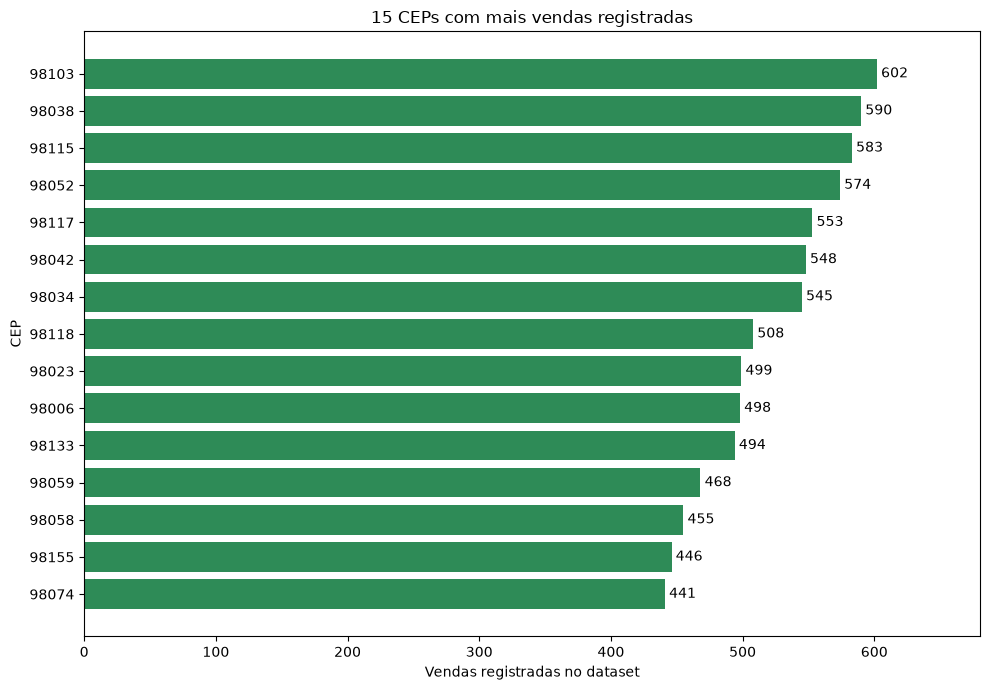

In [13]:
# Mostra os CEPs com mais vendas e sua participação na amostra.
vendas_por_cep = imoveis_com_demografia.groupby("zipcode").size().sort_values(ascending=False)
participacao_ceps = vendas_por_cep.rename("vendas").to_frame()
participacao_ceps["participacao_pct"] = participacao_ceps["vendas"] / len(imoveis_com_demografia) * 100
participacao_ceps["participacao_acumulada_pct"] = participacao_ceps["participacao_pct"].cumsum()
participacao_ceps.to_csv(PASTA_RESULTADOS / "eda_pos_merge_concentracao_ceps.csv")

maiores_ceps = participacao_ceps.head(15).sort_values("vendas")
figura, eixo = plt.subplots(figsize=(10, 7))
barras = eixo.barh(maiores_ceps.index, maiores_ceps["vendas"], color="#2E8B57")
eixo.bar_label(barras, padding=3)
eixo.set(xlabel="Vendas registradas no dataset", ylabel="CEP",
         title="15 CEPs com mais vendas registradas")
eixo.set_xlim(0, maiores_ceps["vendas"].max() * 1.13)
# Remove as linhas de grade do gráfico de barras.
eixo.grid(False)
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "eda_pos_merge_vendas_por_cep.png", dpi=150)
plt.show()

**O que o resultado mostra**

O CEP 98103 tem o maior número de registros: 602. Os 15 primeiros CEPs concentram 36,1% das vendas da amostra. Uma barra maior significa mais registros, não imóveis mais caros.

**Por que fizemos esta análise e o que decidimos**

Medimos a concentração para entender quais regiões mais influenciam análises por venda e o futuro treinamento. Isso não permite afirmar quais bairros têm maior demanda, pois não conhecemos a cobertura da coleta nem o total de imóveis disponíveis.

**Hipótese**

Diferenças de tamanho das regiões, volume de transações ou cobertura do arquivo podem explicar as contagens. A hipótese será investigada com documentação; na modelagem, acompanharemos erros por CEP junto com o número de exemplos.

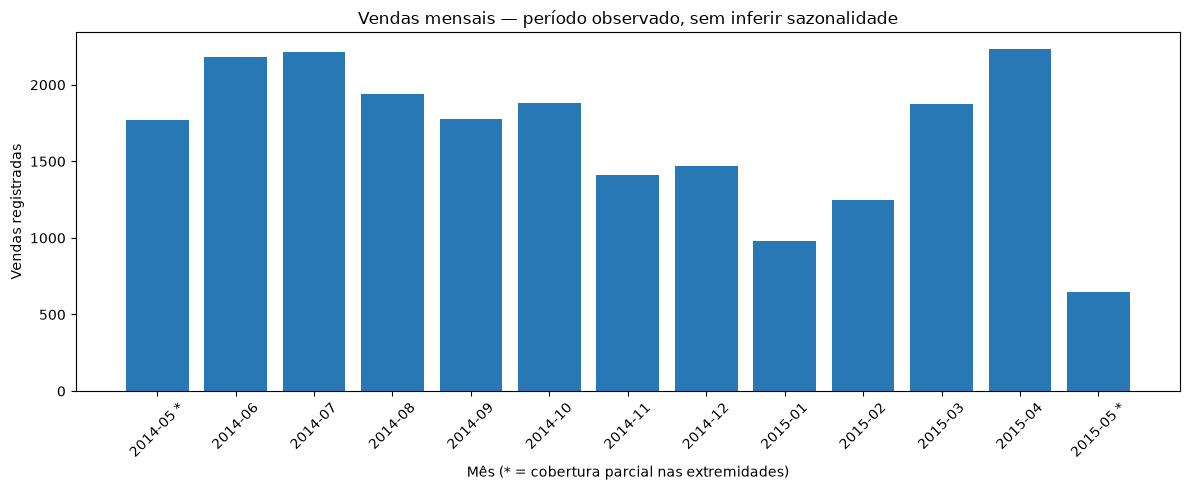

In [14]:
# Conta vendas por mês e destaca os meses com cobertura parcial.
datas_analise = pd.to_datetime(imoveis_com_demografia["date"], format="%Y%m%dT%H%M%S")
vendas_mensais = datas_analise.dt.to_period("M").value_counts().sort_index().rename("vendas").to_frame()
vendas_mensais["cobertura"] = "entre os limites do período observado"
if datas_analise.min().day != 1:
    vendas_mensais.loc[datas_analise.min().to_period("M"), "cobertura"] = "mês inicial parcial"
if datas_analise.max().day != datas_analise.max().days_in_month:
    vendas_mensais.loc[datas_analise.max().to_period("M"), "cobertura"] = "mês final parcial"
vendas_mensais.to_csv(PASTA_RESULTADOS / "eda_pos_merge_vendas_mensais.csv")
rotulos_meses = [
    str(mes) + (" *" if "parcial" in cobertura else "")
    for mes, cobertura in vendas_mensais["cobertura"].items()
]
figura, eixo = plt.subplots(figsize=(12, 5))
eixo.bar(rotulos_meses, vendas_mensais["vendas"], color="#2878B5")
eixo.set(xlabel="Mês (* = cobertura parcial nas extremidades)", ylabel="Vendas registradas",
         title="Vendas mensais — período observado, sem inferir sazonalidade")
eixo.tick_params(axis="x", rotation=45)
# Remove as linhas de grade do gráfico de barras.
eixo.grid(False)
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "eda_pos_merge_vendas_mensais.png", dpi=150)
plt.show()

**O que o resultado mostra**

O período vai de 02/05/2014 a 27/05/2015. O maior número de registros ocorre em 2015-04, com 2.231 vendas. Os meses inicial e final são parciais, portanto suas contagens não são diretamente comparáveis às de meses inteiros.

**Por que fizemos esta análise e o que decidimos**

A distribuição temporal ajuda a planejar a futura divisão dos dados e verificar desequilíbrios. Pouco mais de um ano não sustenta uma conclusão de sazonalidade recorrente. Mesmo meses entre as extremidades não têm garantia de todas as vendas do mercado.

**Hipótese**

A variação pode refletir comportamento do mercado ou diferenças de coleta. Se modelos tiverem desempenho diferente entre períodos, será preciso investigar essas possibilidades sem atribuir automaticamente a causa à estação do ano.

## 5. Outliers: preços incomuns são necessariamente erros?

Não. Um outlier é um valor distante da maior parte dos valores segundo uma regra. Usaremos o intervalo entre os percentis 25% e 75% (IQR) e limites ampliados em 1,5 vez esse intervalo. Compararemos a regra no histórico inteiro e dentro de cada CEP.

**Mediana não trata nem remove outliers:** ela apenas resume o centro com menor influência deles. Os sinais desta seção são descritivos. Nenhuma linha é removida ou limitada, e os sinais de outlier não entram no modelo. Um eventual tratamento por limites seria um experimento futuro, aprendendo os limites somente no treino.

In [15]:
# Compara preços extremos no histórico inteiro e dentro de cada CEP.
analise_extremos = imoveis_com_demografia[["id", "zipcode", "price", "sqft_living", "bedrooms", "grade"]].copy()
primeiro_quartil, terceiro_quartil = analise_extremos["price"].quantile([0.25, 0.75])
intervalo_global = terceiro_quartil - primeiro_quartil
limite_inferior_global = primeiro_quartil - 1.5 * intervalo_global
limite_superior_global = terceiro_quartil + 1.5 * intervalo_global
analise_extremos["extremo_global"] = (
    (analise_extremos["price"] < limite_inferior_global) |
    (analise_extremos["price"] > limite_superior_global)
)
precos_agrupados = analise_extremos.groupby("zipcode")["price"]
quartil_inferior_cep = precos_agrupados.transform("quantile", 0.25)
quartil_superior_cep = precos_agrupados.transform("quantile", 0.75)
intervalo_cep = quartil_superior_cep - quartil_inferior_cep
analise_extremos["extremo_no_cep"] = (
    (analise_extremos["price"] < quartil_inferior_cep - 1.5 * intervalo_cep) |
    (analise_extremos["price"] > quartil_superior_cep + 1.5 * intervalo_cep)
)
analise_extremos["classificacao"] = np.select(
    [analise_extremos["extremo_global"] & analise_extremos["extremo_no_cep"],
     analise_extremos["extremo_global"], analise_extremos["extremo_no_cep"]],
    ["Extremo nas duas regras", "Somente no histórico inteiro", "Somente dentro do CEP"],
    default="Não sinalizado",
)
resumo_extremos = analise_extremos["classificacao"].value_counts().rename("vendas").to_frame()
resumo_extremos["percentual"] = resumo_extremos["vendas"] / len(analise_extremos) * 100
resumo_extremos.to_csv(PASTA_RESULTADOS / "eda_pos_merge_outliers_resumo.csv")
analise_extremos.to_csv(PASTA_RESULTADOS / "eda_pos_merge_outliers_diagnostico.csv", index=False)
print("Limites globais de preço:", limite_inferior_global, "a", limite_superior_global)
exibir(resumo_extremos)

Limites globais de preço: -162625.0 a 1129575.0


,vendas,percentual
classificacao,,
Não sinalizado,19907,92.106603
Somente no histórico inteiro,619,2.864017
Somente dentro do CEP,560,2.591033
Extremo nas duas regras,527,2.438347


**O que o resultado mostra**

A regra global sinaliza 1.146 vendas (5,30%). A regra por CEP sinaliza 1.087. Há 619 vendas extremas globalmente que não são extremas dentro de seu CEP, e 560 que só se destacam na comparação local.

**Por que fizemos esta análise e o que decidimos**

A classificação depende do grupo de referência. Um preço alto para o conjunto inteiro pode ser comum numa região cara. Nenhuma das regras confirma erro, e escolher a que remove mais registros não é um objetivo.

**Hipótese**

Parte dos extremos globais pode refletir diferenças legítimas entre regiões. Os extremos locais podem envolver imóveis incomuns ou problemas de cadastro; comparar área, padrão construtivo e fonte dos registros ajudará a investigar.

In [16]:
# Compara o perfil dos imóveis sinalizados sem retirar observações.
perfil_extremos = analise_extremos.groupby("classificacao").agg(
    vendas=("price", "size"),
    preco_mediano=("price", "median"),
    area_mediana=("sqft_living", "median"),
    grade_mediano=("grade", "median"),
    quartos_medianos=("bedrooms", "median"),
)
perfil_extremos.to_csv(PASTA_RESULTADOS / "eda_pos_merge_outliers_perfil.csv")
exibir(perfil_extremos)

,vendas,preco_mediano,area_mediana,grade_mediano,quartos_medianos
classificacao,,,,,
Extremo nas duas regras,527,1600000.0,4120.0,10.0,4.0
Não sinalizado,19907,430000.0,1830.0,7.0,3.0
Somente dentro do CEP,560,755550.0,3149.0,9.0,4.0
Somente no histórico inteiro,619,1385000.0,3530.0,10.0,4.0


**O que o resultado mostra**

Os 527 registros sinalizados nas duas regras têm preço mediano de 1.600.000, área mediana de 4.120 e grade mediano de 10. Nos 19.907 não sinalizados, esses valores são 430.000, 1.830 e 7. A tabela compara também os grupos identificados apenas por uma regra. Cada mediana é calculada separadamente: não descreve necessariamente uma casa real. Ela permite investigar se os preços sinalizados também acompanham características físicas diferentes.

**Por que fizemos esta análise e o que decidimos**

Antes de tratar um extremo, buscamos contexto. Uma casa de grande área e alto padrão pode ter preço legitimamente distante da maioria. Usar medianas nesta tabela facilita a comparação, mas os valores extremos continuam nos dados e podem influenciar o modelo.

**Hipótese**

Diferenças de área e padrão construtivo podem explicar parte dos preços sinalizados. Isso não comprova a validade dos registros. No notebook 03 investigaremos casos e tratamentos candidatos; no 05 compararemos seus efeitos na validação, mantendo o teste final para a avaliação.

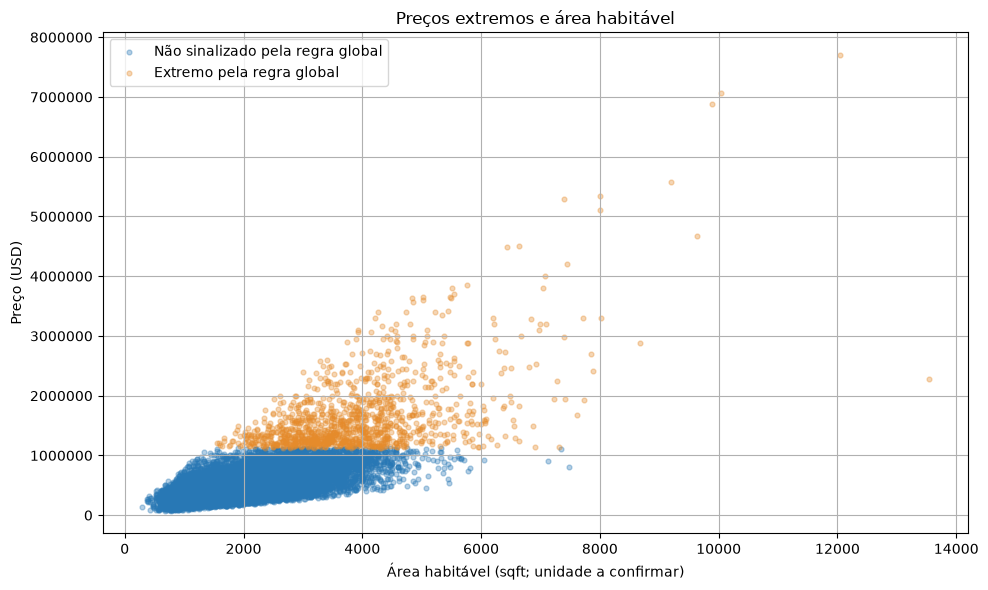

In [17]:
# Compara área e preço destacando os extremos globais.
figura, eixo = plt.subplots(figsize=(10, 6))
for sinalizado, cor, rotulo in [
    (False, "#2878B5", "Não sinalizado pela regra global"),
    (True, "#E58B2B", "Extremo pela regra global"),
]:
    selecao = analise_extremos["extremo_global"].eq(sinalizado)
    eixo.scatter(analise_extremos.loc[selecao, "sqft_living"],
                 analise_extremos.loc[selecao, "price"],
                 color=cor, alpha=0.35, s=12, label=rotulo)
eixo.set(xlabel="Área habitável (sqft; unidade a confirmar)", ylabel="Preço (USD)",
         title="Preços extremos e área habitável")
eixo.ticklabel_format(axis="both", style="plain")
eixo.legend()
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "eda_pos_merge_outliers_area.png", dpi=150)
plt.show()

**O que o resultado mostra**

A cor laranja identifica preços acima ou abaixo dos limites globais calculados; azul identifica as demais vendas. A classificação usa somente o preço: um ponto laranja não é necessariamente estranho em relação à sua área.

**Por que fizemos esta análise e o que decidimos**

A visualização acrescenta contexto à regra estatística. Ela ajuda a procurar casos para revisão, mas não distingue sozinha erro de imóvel de luxo. Os pontos continuam na exportação original, sem alteração de preço.

**Hipótese**

Um modelo que represente relações não lineares entre área, localização e preço pode lidar melhor com parte desses casos. Essa possibilidade será avaliada por métricas e erros por faixa de preço, não apenas pelo desenho do gráfico.

## 6. Salvando o resultado e registrando as decisões

Os arquivos combinados preservam todas as colunas originais e acrescentam os 26 indicadores. A coluna auxiliar de situação da junção fica apenas na memória e no relatório de cobertura. Resumos de preço por CEP e faixas de renda ficam em relatórios descritivos, não nas entradas exportadas para modelagem.

`hous_val_amt` é preservado no merge para permitir investigação. Seu uso no modelo continua pendente de origem, cálculo e data de referência; correlação alta não comprova vazamento. Se forem criadas variáveis agregadas a partir de `price` no futuro, elas deverão ser calculadas somente no treino de cada partição.

In [18]:
# Exporta os dados já conferidos e registra suas fontes.
historico_exportado = imoveis_com_demografia.drop(columns="_situacao_merge")
futuros_exportados = futuros_com_demografia.drop(columns="_situacao_merge")

historico_exportado.to_csv(PASTA_TRATADOS / "imoveis_com_demografia.csv", index=False)
futuros_exportados.to_csv(PASTA_TRATADOS / "futuros_com_demografia.csv", index=False)
registro_execucao = {
    "escopo": "historico_completo_sem_split",
    "historico": {"linhas": len(historico_exportado), "colunas": historico_exportado.shape[1]},
    "futuros": {"linhas": len(futuros_exportados), "colunas": futuros_exportados.shape[1]},
    "indicadores_adicionados": indicadores_demograficos,
    "fontes_sha256": {
        nome: hashlib.sha256((PASTA_ORIGINAIS / nome).read_bytes()).hexdigest()
        for nome in ["kc_house_data.csv", "zipcode_demographics.csv", "future_unseen_examples.csv"]
    },
    "versoes": {"pandas": pd.__version__, "numpy": np.__version__},
    "hous_val_amt": "preservado_na_juncao_uso_no_modelo_pendente",
    "proxima_etapa": "feature_engineering_depois_split_e_modelagem",
}
(PASTA_RESULTADOS / "merge_registro.json").write_text(
    json.dumps(registro_execucao, indent=2, ensure_ascii=False), encoding="utf-8"
)
exibir(pd.DataFrame([
    {"arquivo": "imoveis_com_demografia.csv", "linhas": len(historico_exportado),
     "colunas": historico_exportado.shape[1]},
    {"arquivo": "futuros_com_demografia.csv", "linhas": len(futuros_exportados),
     "colunas": futuros_exportados.shape[1]},
]))

,arquivo,linhas,colunas
0,imoveis_com_demografia.csv,21613,47
1,futuros_com_demografia.csv,100,44


**O que o resultado mostra**

Foram salvos 21.613 registros históricos com 47 colunas e 100 exemplos futuros com 44 colunas. A diferença continua sendo `id`, `date` e `price`. A exportação utiliza diretamente as tabelas conferidas na junção, sem acrescentar agregações de preço.

**Por que fizemos esta análise e o que decidimos**

Os arquivos estão preparados para a próxima etapa sem embutir agregações calculadas com os preços. O registro das fontes permite identificar quais arquivos geraram o resultado. Isso não significa que todas as 44 entradas serão utilizadas no modelo.

## Conclusão para stakeholders

A junção preservou os registros e acrescentou contexto regional, sem ausências demográficas nos arquivos recebidos. As análises mostram associações entre preços e alguns indicadores, mas ainda não medimos se eles melhoram as previsões.

**Hipóteses a levar à modelagem:**

- Indicadores regionais podem complementar características físicas e localização. Comparar modelos com e sem demografia nas mesmas partições.
- Parte das relações pode refletir o tipo de imóvel vendido em cada região. Comparar modelos que já incluam área, classificação e localização antes de atribuir ganho à demografia.
- Alguns indicadores podem repetir informação. Avaliar estabilidade e benefício de grupos de colunas, sem excluir apenas pela correlação.
- `hous_val_amt` pode representar um resumo do mercado local, mas cálculo e período precisam ser confirmados antes de decidir seu uso.

A EDA usou o histórico completo. A próxima etapa será preparar as variáveis; treino, validação e teste serão definidos na modelagem. Nenhuma conclusão aqui demonstra causalidade ou precisão futura.

**Outliers:** as medianas resumem os dados, mas não tratam extremos. Comparamos regras globais, locais e regionais sem remover observações. O notebook 03 cria razões e logaritmos, comparados em grupos no 05. Tratamentos por corte ou remoção de outliers não foram executados e permanecem como melhoria futura.

**Cobertura:** gráficos de CEP e mês descrevem somente as vendas do arquivo; meses parciais e diferenças de representação precisam ser considerados na interpretação.